# 02 -- Why hand-written potentials break

**The Lennard-Jones potential works beautifully for argon. It fails almost everywhere else.**

In Notebook 01 we built a real MD engine. The energy, force, and integrator all work. But there is a catch: the physics we chose -- Lennard-Jones -- is a formula we wrote by hand. That formula captures exactly one thing: a spherically symmetric, two-body interaction dominated by van der Waals attraction and Pauli repulsion.

Real chemistry is more complicated. In this notebook we make that failure concrete:

1. we compare Lennard-Jones to a bond-like potential and see what each can model,
2. we show that LJ cannot model bond breaking,
3. we sketch why angle terms and many-body effects require more than a pair potential.

The lesson is not that classical potentials are useless. The lesson is that *every hand-written potential encodes assumptions*, and the assumptions eventually break. That is the gap machine learning fills.

> **Prerequisites:** Notebook 01.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from afs.md import lj_energy, lj_forces, run_md, disk_cluster, thermal_velocities, triangular_lattice

np.random.seed(42)
rng = np.random.default_rng(42)

## 1. What Lennard-Jones assumes

The LJ potential:

$$V_{LJ}(r) = 4\varepsilon\left[\left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^{6}\right]$$

embeds four assumptions:

1. **Pairwise additivity.** Total energy = sum over pairs. No three-body or many-body effects.
2. **Spherical symmetry.** Only distance $r$ matters, not direction. No preferred angles.
3. **Fixed functional form.** The 12-6 exponents are fixed. The shape cannot adapt.
4. **No bond breaking.** There is a single well; separating atoms just makes the potential go to zero.

For noble gases like argon these are fine. For everything else they fail in different ways.

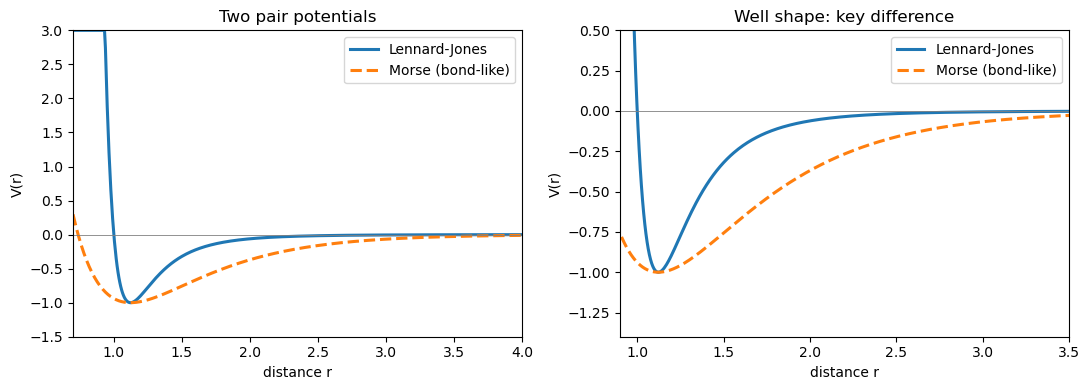

Morse goes to 0 as r -> infinity (bond can break).
LJ also goes to 0, but its well depth is tied to its repulsion --
not an independent, tunable dissociation energy.


In [2]:
# Compare LJ to a Morse potential (more bond-like)
# Morse has a finite dissociation energy and allows bond breaking.

def morse_energy(r, D=1.0, alpha=1.5, r0=1.0):
    return D * (1 - np.exp(-alpha * (r - r0)))**2 - D

r = np.linspace(0.7, 4.0, 500)
v_lj    = 4.0 * (r**-12 - r**-6)
v_morse = morse_energy(r, D=1.0, alpha=1.8, r0=2**(1/6))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(r, np.clip(v_lj, -1.5, 3), label='Lennard-Jones', lw=2.2)
ax.plot(r, v_morse, label='Morse (bond-like)', lw=2.2, ls='--')
ax.axhline(0, color='gray', lw=0.6)
ax.set_ylim(-1.5, 3); ax.set_xlim(0.7, 4.0)
ax.set_xlabel('distance r'); ax.set_ylabel('V(r)')
ax.set_title('Two pair potentials'); ax.legend()

ax = axes[1]
ax.plot(r, np.clip(v_lj, -1.5, 1), label='Lennard-Jones', lw=2.2)
ax.plot(r, v_morse, label='Morse (bond-like)', lw=2.2, ls='--')
ax.axhline(0, color='gray', lw=0.6)
ax.set_xlim(0.9, 3.5); ax.set_ylim(-1.4, 0.5)
ax.set_xlabel('distance r'); ax.set_ylabel('V(r)')
ax.set_title('Well shape: key difference')
ax.legend()

plt.tight_layout()
plt.show()

print('Morse goes to 0 as r -> infinity (bond can break).')
print('LJ also goes to 0, but its well depth is tied to its repulsion --')
print('not an independent, tunable dissociation energy.')

## 2. Failure mode 1: bonds do not break

The most important thing a chemistry potential must do is allow **bonds to form and break** with the right energetics. Chemical reactions are nothing else.

LJ has a well at $r = 2^{1/6}\sigma$, so it *does* hold two atoms together and *does* resist being pulled apart: like any pair potential with a well, its tensile force rises as you separate the atoms, peaks at the inflection of $V$ (for LJ near $r \approx 1.24\,\sigma$), and then decays back to zero once they are far apart. Morse behaves exactly the same way -- so the difference between them is **not** that one has a tensile-force peak and the other does not. Both do, as the force plot below shows.

The real difference is in the *shape and tunability* of the well, and that is what makes LJ a model of van der Waals attraction rather than a chemical bond:

- **The dissociation energy is not a free parameter.** LJ's well depth $\varepsilon$ is the same $\varepsilon$ that sets the repulsion, so you cannot choose a bond strength independently. Morse's $D$ *is* the dissociation energy, tuned on its own.
- **The attractive tail is the wrong physics for a bond.** LJ decays as a power law $r^{-6}$ (long-range van der Waals, correct for closed-shell noble gases); a covalent bond is screened and decays exponentially, which is what Morse does.
- **The repulsion is artificially stiff.** The $r^{-12}$ wall is a computational convenience, not physics; real repulsion is softer.

So LJ is not 'missing the bond-breaking peak' -- it is using van-der-Waals energetics where chemistry needs a tunable, exponentially-screened bond.

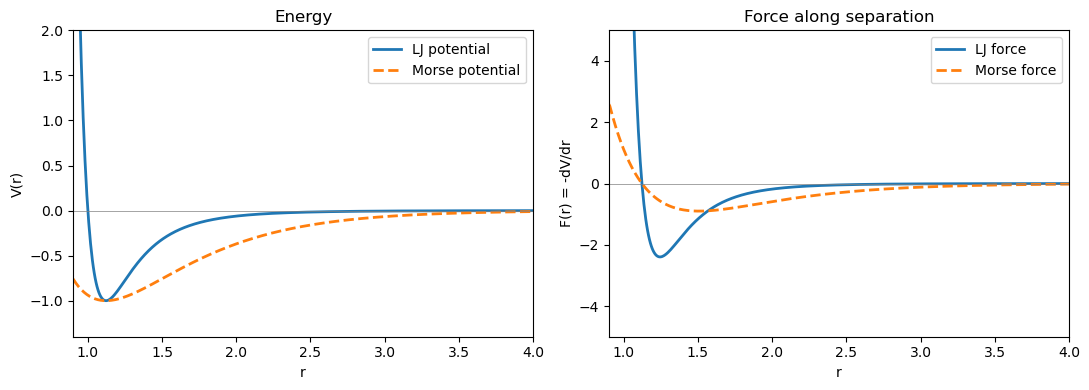

Morse max tensile force near r ~ 1.51
LJ    max tensile force near r ~ 1.24  (LJ has a peak too)
Both dissociate to zero; the real differences are the tunable well depth
and the tail shape (LJ ~ r^-6 van der Waals vs Morse ~ exponential bond).


In [3]:
r = np.linspace(0.9, 4.0, 500)

v_lj    = 4.0 * (r**-12 - r**-6)
v_morse = morse_energy(r, D=1.0, alpha=1.8, r0=2**(1/6))

f_lj    = -np.gradient(v_lj, r)
f_morse = -np.gradient(v_morse, r)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(r, v_lj,    label='LJ potential',    lw=2)
ax.plot(r, v_morse, label='Morse potential', lw=2, ls='--')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlim(0.9, 4.0); ax.set_ylim(-1.4, 2)
ax.set_xlabel('r'); ax.set_ylabel('V(r)'); ax.set_title('Energy'); ax.legend()

ax = axes[1]
ax.plot(r, f_lj,    label='LJ force',    lw=2)
ax.plot(r, f_morse, label='Morse force', lw=2, ls='--')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlim(0.9, 4.0); ax.set_ylim(-5, 5)
ax.set_xlabel('r'); ax.set_ylabel('F(r) = -dV/dr')
ax.set_title('Force along separation')
ax.legend()

plt.tight_layout()
plt.show()

r_inflection_morse = 2**(1/6) + np.log(2)/1.8
r_inflection_lj    = (26/7)**(1/6)          # inflection of V_LJ, in units of sigma
print(f'Morse max tensile force near r ~ {r_inflection_morse:.2f}')
print(f'LJ    max tensile force near r ~ {r_inflection_lj:.2f}  (LJ has a peak too)')
print('Both dissociate to zero; the real differences are the tunable well depth')
print('and the tail shape (LJ ~ r^-6 van der Waals vs Morse ~ exponential bond).')

## 3. Failure mode 2: no directionality

Water (H2O) is the most important molecule on Earth. Its two O-H bonds form an angle of about 104.5 degrees. That angle is why water is a liquid at room temperature, why it has high surface tension, why it is a good solvent.

LJ has no concept of angles. Every atom interacts with every other by the same spherical formula, regardless of direction.

To model water classically, chemists add explicit **angle and bond terms** to the energy:

$$V_{FF} = \sum_{bonds} k_b (r - r_0)^2 + \sum_{angles} k_{\theta} (\theta - \theta_0)^2 + \sum_{pairs} V_{LJ}(r) + \sum_{pairs} \frac{q_i q_j}{r}$$

This is a **force field** -- a recipe with many hand-tuned parameters. Let us implement a minimal version to see what this buys us -- and where it still breaks.

Equilibrium energy: 0.000000  (should be ~0)
H-O-H angle: 109.5 deg  (target: 109.5 deg)


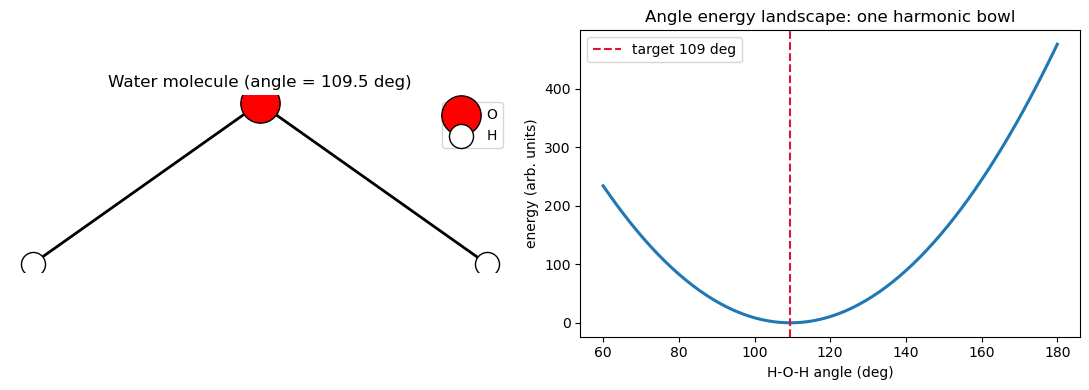

In [4]:
# Minimal water geometry (SPC-like model, illustrative only)
K_BOND  = 502.0          # spring constant (kJ/mol/nm^2)
R0_OH   = 0.1            # equilibrium O-H bond length (nm)
K_ANGLE = 628.0          # angle spring constant (kJ/mol/rad^2)
THETA0  = np.radians(109.47)   # H-O-H equilibrium angle (tetrahedral)

def water_angle(pos_O, pos_H1, pos_H2):
    v1 = pos_H1 - pos_O
    v2 = pos_H2 - pos_O
    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return np.arccos(np.clip(cos_theta, -1, 1))

def water_energy(pos_O, pos_H1, pos_H2):
    r_OH1 = np.linalg.norm(pos_H1 - pos_O)
    r_OH2 = np.linalg.norm(pos_H2 - pos_O)
    theta = water_angle(pos_O, pos_H1, pos_H2)
    E_bond  = 0.5 * K_BOND  * ((r_OH1 - R0_OH)**2 + (r_OH2 - R0_OH)**2)
    E_angle = 0.5 * K_ANGLE * (theta - THETA0)**2
    return E_bond + E_angle

# Place a water molecule at equilibrium
O  = np.array([0.0, 0.0])
H1 = np.array([ R0_OH * np.sin(THETA0/2), -R0_OH * np.cos(THETA0/2)])
H2 = np.array([-R0_OH * np.sin(THETA0/2), -R0_OH * np.cos(THETA0/2)])

print(f'Equilibrium energy: {water_energy(O, H1, H2):.6f}  (should be ~0)')
print(f'H-O-H angle: {np.degrees(water_angle(O, H1, H2)):.1f} deg  (target: {np.degrees(THETA0):.1f} deg)')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
for H in [H1, H2]:
    ax.plot([O[0], H[0]], [O[1], H[1]], 'k-', lw=2, zorder=1)
ax.scatter(*O,  s=800, color='red',   label='O', zorder=2, edgecolors='k')
ax.scatter(*H1, s=300, color='white', label='H', zorder=2, edgecolors='k')
ax.scatter(*H2, s=300, color='white', zorder=2, edgecolors='k')
ax.set_aspect('equal')
ax.set_title(f'Water molecule (angle = {np.degrees(THETA0):.1f} deg)')
ax.legend(); ax.axis('off')

# Energy landscape: vary the H-O-H angle
angles_deg = np.linspace(60, 180, 200)
E_scan = [
    water_energy(
        O,
        np.array([ R0_OH * np.sin(np.radians(a)/2), -R0_OH * np.cos(np.radians(a)/2)]),
        np.array([-R0_OH * np.sin(np.radians(a)/2), -R0_OH * np.cos(np.radians(a)/2)])
    ) for a in angles_deg
]

ax = axes[1]
ax.plot(angles_deg, E_scan, lw=2.2)
ax.axvline(np.degrees(THETA0), color='crimson', ls='--',
           label=f'target {np.degrees(THETA0):.0f} deg')
ax.set_xlabel('H-O-H angle (deg)'); ax.set_ylabel('energy (arb. units)')
ax.set_title('Angle energy landscape: one harmonic bowl')
ax.legend()

plt.tight_layout()
plt.show()

## 4. The transferability problem

Even if we accept all the approximations, classical force fields hit a fundamental wall: **the parameters fit for one molecule do not transfer to another**.

We can tune the O-H spring constant to make the bond vibrate at the right frequency in an isolated water molecule. But in liquid water, each molecule interacts with its neighbours and those interactions subtly change the bond's response. In an enzyme active site, the same water molecule sits next to a metal ion and a charged amino acid -- everything changes again.

Classical force fields patch this by adding more and more terms -- polarisability, charge-on-spring, multipoles -- and re-fitting parameters for every new environment. This works but does not scale. Each new material requires a new fit.

Let us make this concrete by comparing what different functional forms are needed for noble gases, ionic materials, and metals.

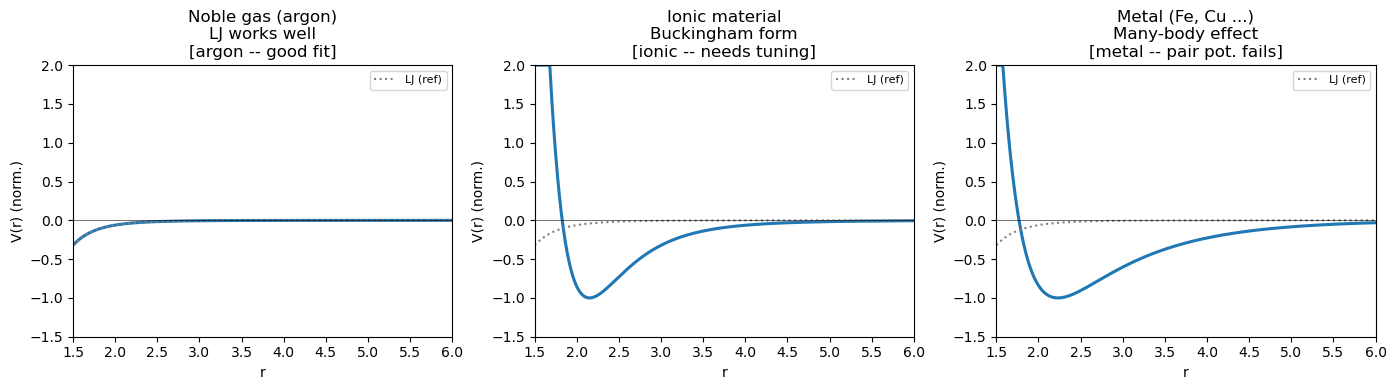

argon : LJ is a reasonable model (spherical, van der Waals)
ionic : need Coulomb terms and different repulsion -- LJ is wrong in detail
metal : many-body embedding energy; a pair potential cannot capture
        the difference between a surface atom and a bulk atom.

One formula cannot rule them all.


In [5]:
r = np.linspace(1.5, 6.0, 400)

# Noble gas (argon): LJ is essentially correct
v_lj = 4.0 * (r**-12 - r**-6)

# Buckingham potential -- alternative for ionic materials
# V = A*exp(-B*r) - C/r^6  (softer repulsion, used for NaCl etc.)
A, B_buck, C = 8000.0, 4.5, 80.0
v_buck = A * np.exp(-B_buck * r) - C / r**6
v_buck_norm = v_buck / max(abs(v_buck.min()), 1e-9)  # normalize for display

# Finnis-Sinclair style (metals): embedding energy depends on sqrt of density
# This is a MANY-BODY effect -- cannot be expressed as a sum of pair terms
rho   = np.exp(-2 * (r - 2.0))
v_metal = -np.sqrt(rho) + 0.5 * np.exp(-4 * (r - 2.0))
v_metal_norm = v_metal / abs(v_metal.min())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

configs = [
    ('Noble gas (argon)\nLJ works well',     v_lj,          'argon -- good fit'),
    ('Ionic material\nBuckingham form',       v_buck_norm,   'ionic -- needs tuning'),
    ('Metal (Fe, Cu ...)\nMany-body effect',  v_metal_norm,  'metal -- pair pot. fails'),
]

for ax, (label, v, note) in zip(axes, configs):
    ax.plot(r, np.clip(v, -1.5, 2.0), lw=2.2)
    ax.plot(r, np.clip(v_lj, -1.5, 2.0), lw=1.5, ls=':', color='gray', label='LJ (ref)')
    ax.axhline(0, color='k', lw=0.4)
    ax.set_xlim(1.5, 6.0); ax.set_ylim(-1.5, 2.0)
    ax.set_xlabel('r'); ax.set_ylabel('V(r) (norm.)')
    ax.set_title(label + f'\n[{note}]')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('argon : LJ is a reasonable model (spherical, van der Waals)')
print('ionic : need Coulomb terms and different repulsion -- LJ is wrong in detail')
print('metal : many-body embedding energy; a pair potential cannot capture')
print('        the difference between a surface atom and a bulk atom.')
print()
print('One formula cannot rule them all.')

## 5. What machine learning gives us -- and what it costs

The key insight of machine-learning potentials (MLPs) is simple:

> Instead of choosing a functional form by physics intuition and fitting parameters by hand, let a neural network learn the function from data.

The MD loop from Notebook 01 does not change at all:

```python
forces = lj_forces(positions)   # notebook 01: hand-written formula
forces = nn_forces(positions)   # notebook 03: a neural network
```

The interface is identical. Velocity-Verlet, energy conservation, and the force-gradient check all carry over unchanged.

**What we gain:**
- Universality: one architecture can fit any material if trained on the right data.
- Accuracy: can approach quantum-chemistry accuracy at a fraction of the cost.
- Transferability: if training data covers diverse environments, the potential transfers.

**What we pay:**
- We need training data (quantum chemistry calculations are expensive).
- The potential is only valid within the distribution of its training data. Outside that distribution it can fail *silently* -- producing a trajectory that looks fine but is physically wrong. That silent failure is Notebook 07.

### Summary: what every hand-written potential cannot do

| Assumption | LJ says | Reality says |
|---|---|---|
| Pairwise only | assumed | many-body effects exist |
| Spherically symmetric | assumed | bonds have directions |
| Fixed functional form | chosen once | different for every material |
| Bond breaking | cannot model | required for chemistry |

Every row in that table is something a neural-network potential can, in principle, learn away.

### Exercises

1. **Morse dynamics.** Implement `morse_forces(positions, D, alpha, r0)`    using a finite-difference gradient. Run an MD simulation of a diatomic 'molecule'    starting at 1.5x the equilibrium distance with LJ vs Morse. What happens?

2. **Three-body check.** Add a third atom to a triangular configuration.    Compare LJ energy (pairwise sum) to the Axilrod-Teller three-body correction    (look up the formula). By what percentage does the pairwise approximation err?

3. **Force-field fitting.** Write a function that evaluates the vibrational frequencies    of the water molecule as a function of K_BOND and K_ANGLE.    Use scipy.optimize.minimize to fit them to target frequencies.    What is the trade-off between fitting geometry vs. frequencies?